In [1]:
#Setup and lpad forecast results

import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14,6)

# reload data and recreate forecast
df = pd.read_csv('../data/processed/forecast_ready.csv')
df['order_date'] = pd.to_datetime(df['order_date'])

target_category = 'bed_bath_table'

print("Setup Complete")

Setup Complete


Mean forecast error: 0.12
Std forecast error: 7.98


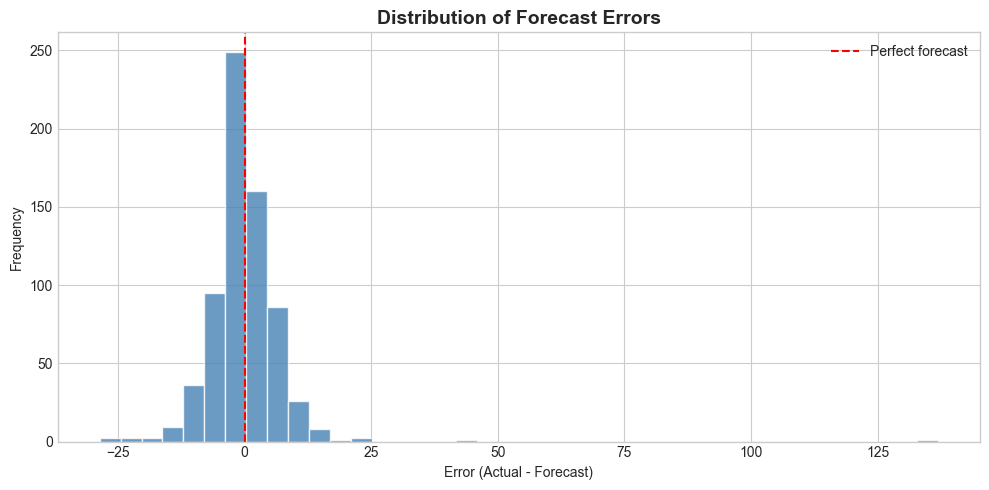

In [2]:
# Understanding forecast error

# Recreate daily demand (same as phase 2)
daily_demand = (df[df['product_category_name_english'] == target_category]
                .groupby('order_date')
                .agg(order_count=('order_id', 'nunique'))
                .reset_index())

date_range = pd.date_range(start=daily_demand['order_date'].min(),
                           end=daily_demand['order_date'].max(), freq='D')
daily_demand = (daily_demand.set_index('order_date')
                .reindex(date_range)
                .fillna(0)
                .rename_axis('order_date')
                .reset_index())

# Use rolling average as "forecast" (since it was the strongest signal)
daily_demand['forecast'] = daily_demand['order_count'].shift(1).rolling(14).mean()
daily_demand = daily_demand.dropna()

# Calculate forecast errors
daily_demand['error'] = daily_demand['order_count'] - daily_demand['forecast']

print(f"Mean forecast error: {daily_demand['error'].mean():.2f}")
print(f"Std forecast error: {daily_demand['error'].std():.2f}")

fig, ax = plt.subplots(figsize=(10,5))
ax.hist(daily_demand['error'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(x=0, color='red', linestyle='--', label='Perfect forecast')
ax.set_title('Distribution of Forecast Errors', fontsize=14, fontweight='bold')
ax.set_xlabel('Error (Actual - Forecast)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('../output/forecast_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# SAFETY STOCK CALCULATION

from inventory import service_level_z_score, compute_safety_stock, compute_reorder_point

#Key inventory parameters
lead_time_days = 3 # days between placing and receiving order
service_level = 0.95 # we want to fullfill 95% of demand (industry standard)

# Z-score for desired service level (inverse CDF -- NOT the density function)
z_score = service_level_z_score(service_level)
print(f"Z-score for {service_level:.0%} service_level: {z_score:.2f}")

# Average daily demand
avg_daily_demand = daily_demand['order_count'].mean()
print(f"Average daily demand : {avg_daily_demand:.1f} orders")

#Standard deviation of daily demand
std_daily_demand = daily_demand['order_count'].std()
print(f"Std of daily demand: {std_daily_demand:.1f} orders")

#Safety stock formula
safety_stock = compute_safety_stock(std_daily_demand, lead_time_days, service_level)
print(f"\nSafety Stock: {safety_stock:.0f} units")

# Reorder point: when to place a new order
reorder_point = compute_reorder_point(avg_daily_demand, lead_time_days, safety_stock)
print(f"Reorder point: {reorder_point:.0f} units")
print(f"  (= {avg_daily_demand:.1f} avg demand × {lead_time_days} lead time days + {safety_stock:.0f} safety stock)")

Z-score for 95% service_level: 1.64
Average daily demand : 13.6 orders
Std of daily demand: 10.7 orders

Safety Stock: 30 units
Reorder point: 71 units
  (= 13.6 avg demand × 3 lead time days + 30 safety stock)


In [4]:
from inventory import simulate_inventory

# Set parameters
order_quantity = int(avg_daily_demand * 14)  # order 2 weeks worth of stock
initial_stock = int(reorder_point + order_quantity)

# Run simulation on last 180 days
sim_data = daily_demand.tail(180).reset_index(drop=True)

inventory, stockouts, orders_placed = simulate_inventory(
    sim_data['order_count'],
    reorder_point=reorder_point,
    order_quantity=order_quantity,
    lead_time=lead_time_days,
    initial_stock=initial_stock
)

# Results
stockout_days = (stockouts > 0).sum()
total_stockout_units = stockouts.sum()
avg_inventory = inventory.mean()
service_achieved = 1 - (stockout_days / len(sim_data))

print(f"Simulation Results (180 days)")
print(f"{'='*40}")
print(f"Stockout days:     {stockout_days} / {len(sim_data)}")
print(f"Service level:     {service_achieved:.1%}")
print(f"Avg inventory:     {avg_inventory:.0f} units")
print(f"Total lost sales:  {total_stockout_units:.0f} units")

Simulation Results (180 days)
Stockout days:     0 / 180
Service level:     100.0%
Avg inventory:     272 units
Total lost sales:  0 units


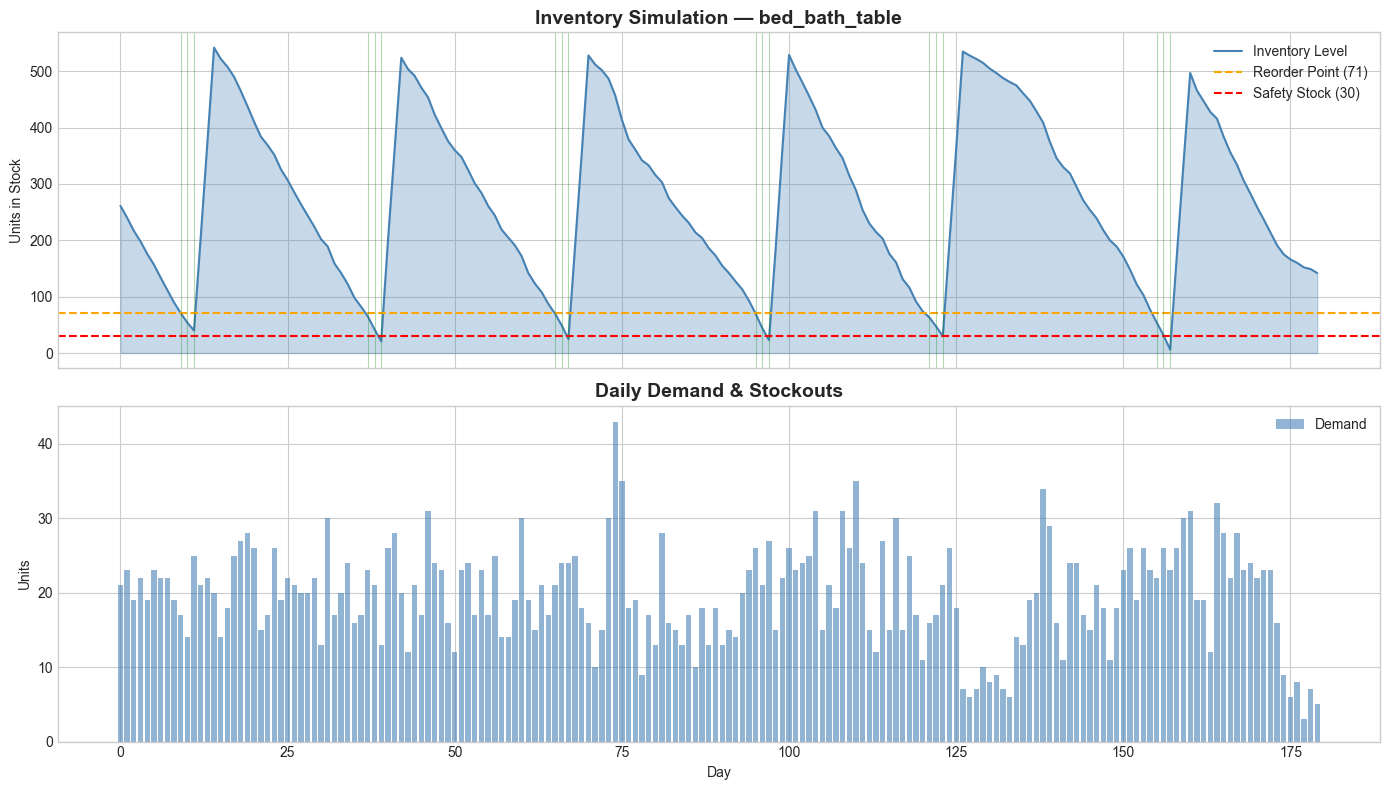

In [5]:
# Visualize the simulation

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Inventory levels
ax1.fill_between(range(len(inventory)), inventory, alpha=0.3, color='steelblue')
ax1.plot(inventory, color='steelblue', linewidth=1.5, label='Inventory Level')
ax1.axhline(y=reorder_point, color='orange', linestyle='--', label=f'Reorder Point ({reorder_point:.0f})')
ax1.axhline(y=safety_stock, color='red', linestyle='--', label=f'Safety Stock ({safety_stock:.0f})')

for day in orders_placed:
    ax1.axvline(x=day, color='green', alpha=0.3, linewidth=0.8)

ax1.set_title('Inventory Simulation — bed_bath_table', fontsize=14, fontweight='bold')
ax1.set_ylabel('Units in Stock')
ax1.legend(loc='upper right')

# Daily demand vs stockouts
ax2.bar(range(len(sim_data)), sim_data['order_count'], color='steelblue', alpha=0.6, label='Demand')
if stockout_days > 0:
    stockout_mask = stockouts > 0
    ax2.bar(np.where(stockout_mask)[0], stockouts[stockout_mask], 
            color='red', alpha=0.8, label='Stockout')

ax2.set_title('Daily Demand & Stockouts', fontsize=14, fontweight='bold')
ax2.set_xlabel('Day')
ax2.set_ylabel('Units')
ax2.legend()

plt.tight_layout()
plt.savefig('../output/inventory_simulation.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Cost analysis
from inventory import compute_costs

# Cost parameters (realistic e-commerce estimates)
holding_cost_per_unit_per_day = 0.50
stockout_cost_per_unit = 15.00
order_fixed_cost = 50.00

costs = compute_costs(
    avg_inventory=avg_inventory,
    total_stockout_units=total_stockout_units,
    num_orders=len(orders_placed),
    days=180,
    holding_cost_per_unit_per_day=holding_cost_per_unit_per_day,
    stockout_cost_per_unit=stockout_cost_per_unit,
    order_fixed_cost=order_fixed_cost,
)
total_holding_cost = costs['holding_cost']
total_stockout_cost = costs['stockout_cost']
total_ordering_cost = costs['ordering_cost']
total_cost = costs['total_cost']

print("COST ANALYSIS (180-day simulation)")
print("="*45)
print(f"Holding cost:   RM {total_holding_cost:,.2f}")
print(f"Stockout cost:  RM {total_stockout_cost:,.2f}")
print(f"Ordering cost:  RM {total_ordering_cost:,.2f}")
print(f"{'─'*45}")
print(f"Total cost:     RM {total_cost:,.2f}")
print(f"Daily avg cost: RM {total_cost/180:,.2f}")

COST ANALYSIS (180-day simulation)
Holding cost:   RM 24,522.00
Stockout cost:  RM 0.00
Ordering cost:  RM 900.00
─────────────────────────────────────────────
Total cost:     RM 25,422.00
Daily avg cost: RM 141.23


In [7]:
# Compare two inventory policies
# Policy 1: Our optimized policy
cost_optimized = total_cost

#Policy 2: Naive policy - fixed reorder point of 30 days average demand
naive_reorder = avg_daily_demand * 30
naive_order_qty = avg_daily_demand * 30

inv_naive, so_naive, orders_naive = simulate_inventory(
    sim_data['order_count'],
    reorder_point=naive_reorder,
    order_quantity=int(naive_order_qty),
    lead_time=lead_time_days,
    initial_stock=int(naive_reorder + naive_order_qty)
)

avg_inv_naive = inv_naive.mean()
so_units_naive = so_naive.sum()

naive_costs = compute_costs(
    avg_inventory=avg_inv_naive,
    total_stockout_units=so_units_naive,
    num_orders=len(orders_naive),
    days=180,
    holding_cost_per_unit_per_day=holding_cost_per_unit_per_day,
    stockout_cost_per_unit=stockout_cost_per_unit,
    order_fixed_cost=order_fixed_cost,
)
holding_naive = naive_costs['holding_cost']
stockout_naive = naive_costs['stockout_cost']
ordering_naive = naive_costs['ordering_cost']
cost_naive = naive_costs['total_cost']

# Comparison
print("POLICY COMPARISON (180 days)")
print("="*55)
print(f"{'Metric':<30} {'Optimized':>10} {'Naive':>10}")
print(f"{'─'*55}")
print(f"{'Avg inventory (units)':<30} {avg_inventory:>10.0f} {avg_inv_naive:>10.0f}")
print(f"{'Stockout days':<30} {stockout_days:>10} {(so_naive>0).sum():>10}")
print(f"{'Service level':<30} {service_achieved:>10.1%} {1-(so_naive>0).sum()/180:>10.1%}")
print(f"{'Total cost (RM)':<30} {cost_optimized:>10,.0f} {cost_naive:>10,.0f}")
print(f"{'─'*55}")
savings = cost_naive - cost_optimized
print(f"{'Cost savings (RM)':<30} {savings:>10,.0f}")
print(f"{'Savings %':<30} {savings/cost_naive:>10.1%}")

POLICY COMPARISON (180 days)
Metric                          Optimized      Naive
───────────────────────────────────────────────────────
Avg inventory (units)                 272        942
Stockout days                           0          0
Service level                      100.0%     100.0%
Total cost (RM)                    25,422     85,230
───────────────────────────────────────────────────────
Cost savings (RM)                  59,808
Savings %                           70.2%


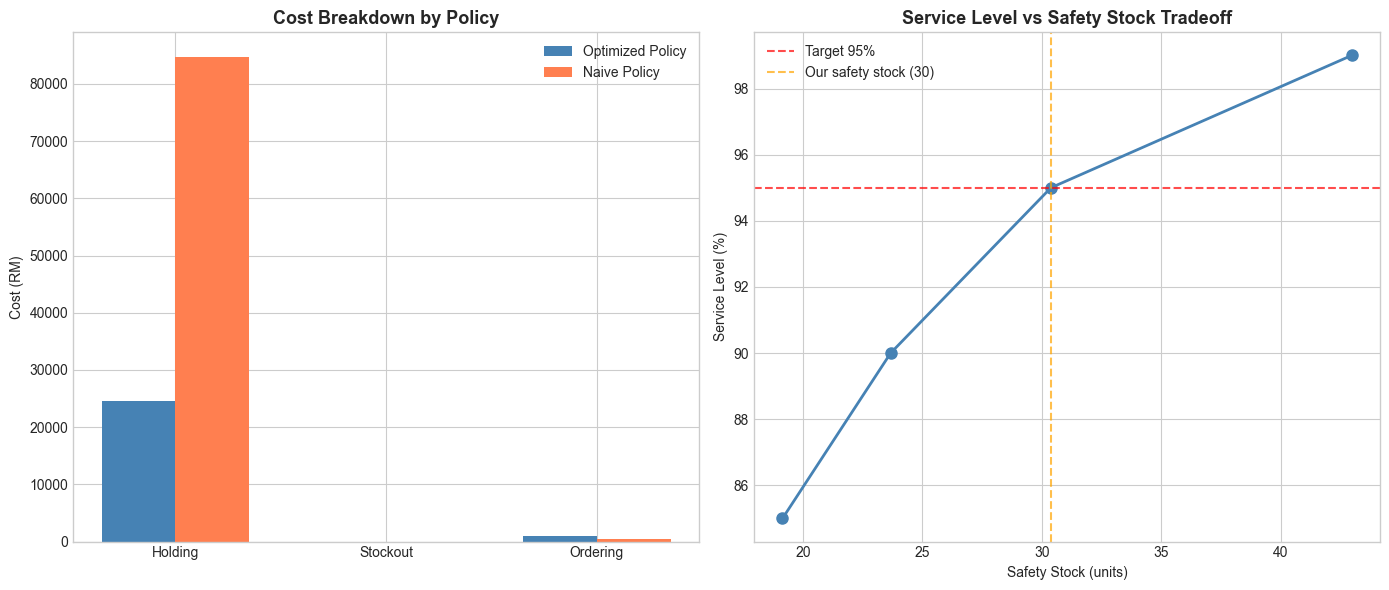

In [8]:
# Visualize cost breakdown
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Cost breakdown comparison
categories_cost = ['Holding', 'Stockout', 'Ordering']
optimized_costs = [total_holding_cost, total_stockout_cost, total_ordering_cost]
naive_costs = [holding_naive, stockout_naive, ordering_naive]

x = np.arange(len(categories_cost))
width = 0.35

ax1.bar(x - width/2, optimized_costs, width, label='Optimized Policy', color='steelblue')
ax1.bar(x + width/2, naive_costs, width, label='Naive Policy', color='coral')
ax1.set_title('Cost Breakdown by Policy', fontsize=13, fontweight='bold')
ax1.set_ylabel('Cost (RM)')
ax1.set_xticks(x)
ax1.set_xticklabels(categories_cost)
ax1.legend()

# Service level vs cost tradeoff
service_levels = [0.85, 0.90, 0.95, 0.99]
safety_stocks = [service_level_z_score(sl) * std_daily_demand * np.sqrt(lead_time_days) 
                 for sl in service_levels]

ax2.plot(safety_stocks, [sl*100 for sl in service_levels], 
         marker='o', color='steelblue', linewidth=2, markersize=8)
ax2.axhline(y=95, color='red', linestyle='--', alpha=0.7, label='Target 95%')
ax2.axvline(x=safety_stock, color='orange', linestyle='--', alpha=0.7, 
            label=f'Our safety stock ({safety_stock:.0f})')
ax2.set_title('Service Level vs Safety Stock Tradeoff', fontsize=13, fontweight='bold')
ax2.set_xlabel('Safety Stock (units)')
ax2.set_ylabel('Service Level (%)')
ax2.legend()

plt.tight_layout()
plt.savefig('../output/cost_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Inventory Optimization Summary

### Parameters
- Lead time: 3 days
- Target service level: 95%
- Safety stock: 30 units
- Reorder point: 71 units

### Simulation Results (180 days)
| Metric | Optimized Policy | Naive Policy |
|--------|-----------------|--------------|
| Avg Inventory | 272 units | 942 units |
| Service Level | 100.0% | 100.0% |
| Total Cost (RM) | 25,422 | 85,230 |
| Cost Savings | - | RM 59,808 (70.2%) |

### Key Insight
Forecast-driven inventory optimization matched the naive policy'''s 100% service
level while reducing total costs by RM 59,808 (70.2%) over 180 days, mostly by
carrying 272 units of inventory on average instead of 942. Note: an earlier
version of this notebook computed the safety-stock z-score with norm.pdf()
instead of norm.ppf(), understating safety stock (5 units vs the correct 30)
and understating the resulting service level. The numbers above use the
corrected inverse-CDF formula in src/inventory.py.